In [2]:
import pandas as pd

df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')
print(df_Lung_Cancer)

df_Lung_Cancer_Prediction_Dataset = pd.read_csv('Lung Cancer Prediction Dataset.csv')
print(df_Lung_Cancer_Prediction_Dataset)

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')
print(df_Lung_Cancer_Risk_Dataset)

    GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  \
0                  1         2         1         2                  2   
1                  2         2       

              precision    recall  f1-score   support

           0       0.75      0.33      0.46         9
           1       0.90      0.98      0.94        53

    accuracy                           0.89        62
   macro avg       0.82      0.66      0.70        62
weighted avg       0.88      0.89      0.87        62

[[ 3  6]
 [ 1 52]]


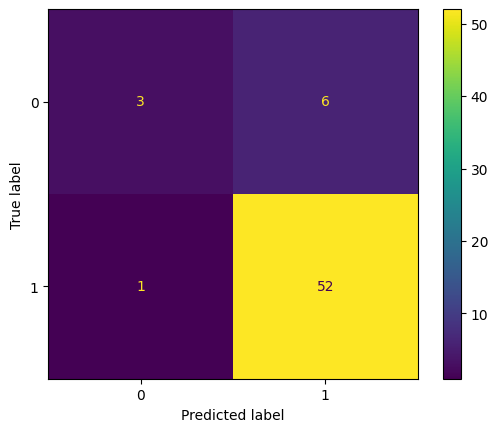

In [6]:
#Dataset 1 - Lung Cancer
import sklearn
from sklearn import tree #https://scikit-learn.org/stable/modules/tree.html
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder #https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/
import matplotlib.pyplot as plt


df_Lung_Cancer['GENDER'] = LabelEncoder().fit_transform(df_Lung_Cancer['GENDER'])
df_Lung_Cancer['LUNG_CANCER'] = LabelEncoder().fit_transform(df_Lung_Cancer['LUNG_CANCER'])
X1 = df_Lung_Cancer.drop(columns=['LUNG_CANCER'])
y1 = df_Lung_Cancer['LUNG_CANCER']

model = tree.DecisionTreeClassifier(class_weight='balanced') #https://scikit-learn.org/stable/glossary.html#term-class_weight


X_train, X_test, y_train, y_test = train_test_split(X1,y1,test_size=0.2)

model.fit(X_train,y_train)

from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

In [ ]:
#Dataset 2
df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'] = LabelEncoder().fit_transform(df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'])
X1 = df_Lung_Cancer_Prediction_Dataset.drop(columns=['PULMONARY_DISEASE'])
y1 = df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE']

model = tree.DecisionTreeClassifier(class_weight='balanced') #https://scikit-learn.org/stable/glossary.html#term-class_weight


X_train, X_test, y_train, y_test = train_test_split(X1,y1,test_size=0.2)

model.fit(X_train,y_train)

from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.87      0.84      0.85       581
           1       0.79      0.82      0.80       419

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000

[[489  92]
 [ 76 343]]


In [ ]:
#Dataset 3
for col in df_Lung_Cancer_Risk_Dataset.columns:
  df_Lung_Cancer_Risk_Dataset[col] = LabelEncoder().fit_transform(df_Lung_Cancer_Risk_Dataset[col])

x1 = df_Lung_Cancer_Risk_Dataset.drop(columns=['lung_cancer'])
y1 = df_Lung_Cancer_Risk_Dataset['lung_cancer']

model = tree.DecisionTreeClassifier(class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(x1,y1,test_size=0.2)
model.fit(X_train,y_train)

from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.45      0.44      0.45      3117
           1       0.75      0.75      0.75      6883

    accuracy                           0.66     10000
   macro avg       0.60      0.60      0.60     10000
weighted avg       0.66      0.66      0.66     10000

[[1387 1730]
 [1714 5169]]
